# UCI-HAR + ImageNet Pretrained VGG16

실험 구조:
1. UCI-HAR raw inertial signal load
2. Train 기준 standardization
3. `(128, 9)` time-series window를 VGG16용 `(128, 128, 3)` pseudo-image로 변환
4. ImageNet pretrained VGG16 encoder + HAR classifier head 구성
5. Stage 1: Linear Probing
   - VGG16 encoder 전체 동결
   - classifier head만 학습
   - Accuracy / Macro F1 평가
6. Stage 2: Fine-tuning
   - VGG16 block5만 동결 해제
   - block5 + classifier head 학습
   - Accuracy / Macro F1 평가
7. 마지막에 성능 비교표, 같은 class 거리 비교표, t-SNE 시각화 출력

In [3]:
# Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    pairwise_distances
)
from sklearn.manifold import TSNE

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# 1. Basic Settings

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = "/content/drive/MyDrive/UCI HAR Dataset"

SIGNAL_NAMES = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

NUM_CLASSES = 6
BATCH_SIZE = 64

HEAD_EPOCHS = 30
FINETUNE_EPOCHS = 40

IMG_SIZE = 128

LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

# t-SNE / distance analysis settings
N_TSNE_SAMPLES = 1000
TARGET_CLASS = 0          # 0 = WALKING
N_DISTANCE_SAMPLES = 100
EMBEDDING_LAYER_FOR_ANALYSIS = "head_embedding"
DISTANCE_METRIC = "cosine"

In [6]:
# 2. Load UCI-HAR Raw Inertial Signals

def load_signals(split):
    signal_dir = os.path.join(BASE_DIR, split, "Inertial Signals")
    signals = []

    for name in SIGNAL_NAMES:
        file_path = os.path.join(signal_dir, f"{name}_{split}.txt")
        data = np.loadtxt(file_path)
        signals.append(data)

    # (N, 128, 9)
    signals = np.stack(signals, axis=-1).astype(np.float32)
    return signals


def load_labels(split):
    label_path = os.path.join(BASE_DIR, split, f"y_{split}.txt")
    labels = np.loadtxt(label_path).astype(np.int64)

    # UCI-HAR labels are 1~6, convert to 0~5
    labels = labels - 1
    return labels


X_train = load_signals("train")
y_train = load_labels("train")

X_test = load_signals("test")
y_test = load_labels("test")

print("Original train:", X_train.shape, y_train.shape)
print("Original test :", X_test.shape, y_test.shape)

Original train: (7352, 128, 9) (7352,)
Original test : (2947, 128, 9) (2947,)


In [7]:
# 3. Train-only Standardization

N_train, T, C = X_train.shape
N_test = X_test.shape[0]

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, C)
X_test_2d = X_test.reshape(-1, C)

X_train = scaler.fit_transform(X_train_2d).reshape(N_train, T, C).astype(np.float32)
X_test = scaler.transform(X_test_2d).reshape(N_test, T, C).astype(np.float32)

print("After standardization:", X_train.shape, X_test.shape)

After standardization: (7352, 128, 9) (2947, 128, 9)


In [8]:
# 4. Convert Time-series Window to VGG Input Image
# Original UCI-HAR window: (128, 9)
# Converted VGG input    : (128, 128, 3)

def timeseries_to_vgg_image(x, y):
    x = tf.expand_dims(x, axis=-1)               # (128, 9, 1)
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE)) # (128, 128, 1)
    x = tf.repeat(x, repeats=3, axis=-1)         # (128, 128, 3)

    # Convert standardized signal to pseudo image intensity range
    x = tf.clip_by_value(x, -3.0, 3.0)
    x = (x + 3.0) / 6.0
    x = x * 255.0

    x = preprocess_input(x)
    return x, y


def build_dataset(X, y, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)

    ds = ds.map(timeseries_to_vgg_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = build_dataset(X_train, y_train, training=True)
test_ds = build_dataset(X_test, y_test, training=False)

In [9]:
# 5. Build ImageNet Pretrained VGG16 Classifier
# Model structure:
# input -> VGG16 encoder -> encoder_embedding -> classifier head -> softmax
#
# encoder_embedding: VGG16 feature vector after GlobalAveragePooling2D
# head_embedding   : classifier head 내부의 분류 직전 표현

def build_pretrained_vgg16_model(num_classes=6):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    base_model = VGG16(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    # Stage 1 starts with frozen pretrained VGG16 encoder
    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D(name="encoder_embedding")(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu", name="head_embedding")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Pretrained_VGG16_UCIHAR")

    return model, base_model


model, base_model = build_pretrained_vgg16_model(num_classes=NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "Pretrained_VGG16_UCIHAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_embedding               │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_embedding (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 164,998 (644.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
# 6. Utility Functions

def evaluate_model_simple(model, test_ds, y_test, class_names, stage_name):
    print(f"================ {stage_name} Evaluation ================")

    y_prob = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d"
    )
    plt.title(f"Confusion Matrix - {stage_name}")
    plt.tight_layout()
    plt.show()

    result = {
        "stage": stage_name,
        "accuracy": acc,
        "macro_f1": macro_f1
    }

    return result, cm


def extract_embeddings(model, X, y, layer_name="head_embedding", n_samples=1000):
    n_samples = min(n_samples, len(X))

    X_sample = X[:n_samples]
    y_sample = y[:n_samples]

    ds_sample = build_dataset(X_sample, y_sample, training=False)

    embedding_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.get_layer(layer_name).output
    )

    embeddings = embedding_model.predict(ds_sample, verbose=1)

    return embeddings, y_sample


def calculate_intra_class_distance(embeddings, metric="cosine"):
    distances = pairwise_distances(embeddings, metric=metric)

    # exclude self-distance by using upper triangle only
    upper_idx = np.triu_indices_from(distances, k=1)
    pair_distances = distances[upper_idx]

    return {
        "mean_distance": pair_distances.mean(),
        "std_distance": pair_distances.std(),
        "min_distance": pair_distances.min(),
        "max_distance": pair_distances.max()
    }


def measure_same_class_distance(
    model,
    X,
    y,
    target_class,
    class_names,
    stage_name,
    layer_name="head_embedding",
    n_samples=100,
    metric="cosine"
):
    idx = np.where(y == target_class)[0]
    idx = idx[:n_samples]

    X_selected = X[idx]
    y_selected = y[idx]

    embeddings, _ = extract_embeddings(
        model=model,
        X=X_selected,
        y=y_selected,
        layer_name=layer_name,
        n_samples=len(X_selected)
    )

    distance_result = calculate_intra_class_distance(
        embeddings=embeddings,
        metric=metric
    )

    result = {
        "stage": stage_name,
        "target_class": class_names[target_class],
        "layer": layer_name,
        "metric": metric,
        **distance_result
    }

    print(f"================ {stage_name} Same-Class Distance ================")
    print(f"Target class  : {class_names[target_class]}")
    print(f"Layer         : {layer_name}")
    print(f"Metric        : {metric}")
    print(f"Mean distance : {distance_result['mean_distance']:.4f}")
    print(f"Std distance  : {distance_result['std_distance']:.4f}")

    return result


def plot_tsne_comparison_row(
    embeddings_list,
    y,
    class_names,
    titles,
    random_state=42
):
    print("================ t-SNE Comparison ================")

    fig, axes = plt.subplots(
        1,
        len(embeddings_list),
        figsize=(18, 5),
        constrained_layout=True
    )

    if len(embeddings_list) == 1:
        axes = [axes]

    tsne_results = []

    for ax, embeddings, title in zip(axes, embeddings_list, titles):
        print(f"{title} embedding shape: {embeddings.shape}")

        # perplexity should be smaller than sample size
        perplexity = min(30, max(5, (len(embeddings) - 1) // 3))

        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate="auto",
            init="pca",
            random_state=random_state
        )

        embeddings_2d = tsne.fit_transform(embeddings)
        tsne_results.append(embeddings_2d)

        for class_idx, class_name in enumerate(class_names):
            idx = y == class_idx

            ax.scatter(
                embeddings_2d[idx, 0],
                embeddings_2d[idx, 1],
                s=10,
                alpha=0.75,
                label=class_name
            )

        ax.set_title(title)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    handles, labels = axes[-1].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Activity",
        loc="center right",
        bbox_to_anchor=(1.08, 0.5)
    )

    plt.show()

    return tsne_results

In [11]:
# 7. Before Training: Extract Embedding + Same-Class Distance
# 학습 전 head_embedding은 아직 랜덤 초기화된 classifier head를 통과한 표현.
# 이후 Stage 1, Stage 2와 같은 layer 기준으로 비교하기 위해 head_embedding을 저장

emb_before, y_vis = extract_embeddings(
    model=model,
    X=X_test,
    y=y_test,
    layer_name=EMBEDDING_LAYER_FOR_ANALYSIS,
    n_samples=N_TSNE_SAMPLES
)

before_distance = measure_same_class_distance(
    model=model,
    X=X_test,
    y=y_test,
    target_class=TARGET_CLASS,
    class_names=class_names,
    stage_name="Before Training",
    layer_name=EMBEDDING_LAYER_FOR_ANALYSIS,
    n_samples=N_DISTANCE_SAMPLES,
    metric=DISTANCE_METRIC
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 624ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 6s/step
================ Before Training Same-Class Distance ================
Target class  : WALKING
Layer         : head_embedding
Metric        : cosine
Mean distance : 0.0403
Std distance  : 0.0165


================ Stage 1: Linear Probing ================
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 203ms/step - accuracy: 0.6952 - loss: 0.9723 - learning_rate: 0.0010
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.8486 - loss: 0.3989 - learning_rate: 0.0010
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.8740 - loss: 0.3229 - learning_rate: 0.0010
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8924 - loss: 0.2770 - learning_rate: 0.0010
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - accuracy: 0.9093 - loss: 0.2369 - learning_rate: 0.0010
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.9143 - loss: 0.2237 - learning_rate: 0.0010
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - accuracy: 0.9211 - loss: 0.1998 - learning_rate: 0.0010
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.9271 - loss: 0.1847 - learning_rate: 0.0010
Epoch 9/30
115/115 ━━━━━━━━━━━━━━━━━━━

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step
Accuracy : 0.8880
Macro F1 : 0.8848


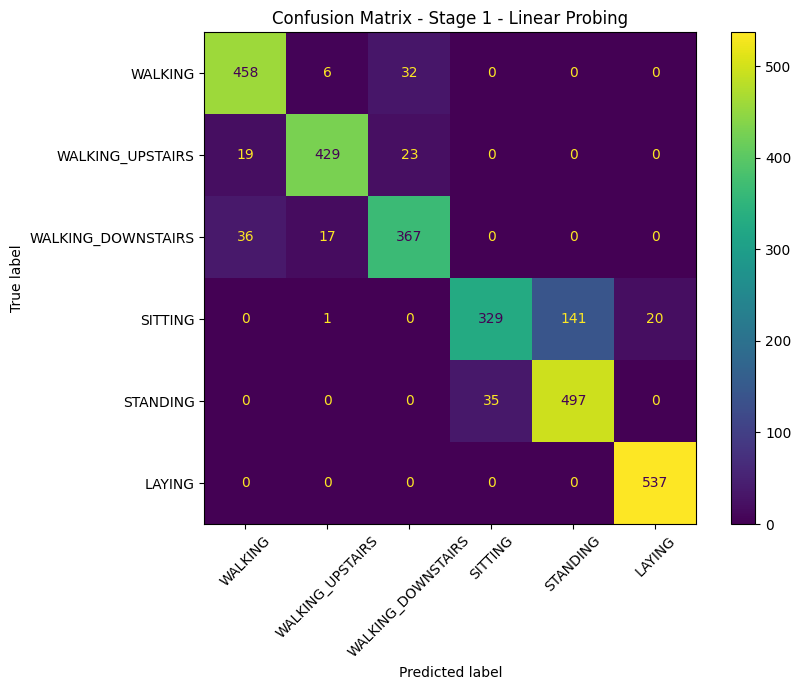

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
================ Stage 1 - Linear Probing Same-Class Distance ================
Target class  : WALKING
Layer         : head_embedding
Metric        : cosine
Mean distance : 0.1047
Std distance  : 0.0913


In [12]:
# 8. Stage 1: Linear Probing
# Encoder state:
# - VGG16 encoder frozen.
# - Only the classifier head is trained.

print("================ Stage 1: Linear Probing ================")

base_model.trainable = False
for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage1 = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

history_stage1 = model.fit(
    train_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_stage1,
    verbose=1
)

stage1_result, stage1_cm = evaluate_model_simple(
    model=model,
    test_ds=test_ds,
    y_test=y_test,
    class_names=class_names,
    stage_name="Stage 1 - Linear Probing"
)

emb_stage1, _ = extract_embeddings(
    model=model,
    X=X_test,
    y=y_test,
    layer_name=EMBEDDING_LAYER_FOR_ANALYSIS,
    n_samples=N_TSNE_SAMPLES
)

stage1_distance = measure_same_class_distance(
    model=model,
    X=X_test,
    y=y_test,
    target_class=TARGET_CLASS,
    class_names=class_names,
    stage_name="Stage 1 - Linear Probing",
    layer_name=EMBEDDING_LAYER_FOR_ANALYSIS,
    n_samples=N_DISTANCE_SAMPLES,
    metric=DISTANCE_METRIC
)

================ Stage 2: Fine-tune VGG Block5 ================
================ Trainable Layers Before Stage 2 ================
input_layer               trainable=False
block1_conv1              trainable=False
block1_conv2              trainable=False
block1_pool               trainable=False
block2_conv1              trainable=False
block2_conv2              trainable=False
block2_pool               trainable=False
block3_conv1              trainable=False
block3_conv2              trainable=False
block3_conv3              trainable=False
block3_pool               trainable=False
block4_conv1              trainable=False
block4_conv2              trainable=False
block4_conv3              trainable=False
block4_pool               trainable=False
block5_conv1              trainable=True
block5_conv2              trainable=True
block5_conv3              trainable=True
block5_pool               trainable=True
Epoch 1/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step - accuracy: 0.9682 - 

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step
Accuracy : 0.9321
Macro F1 : 0.9317


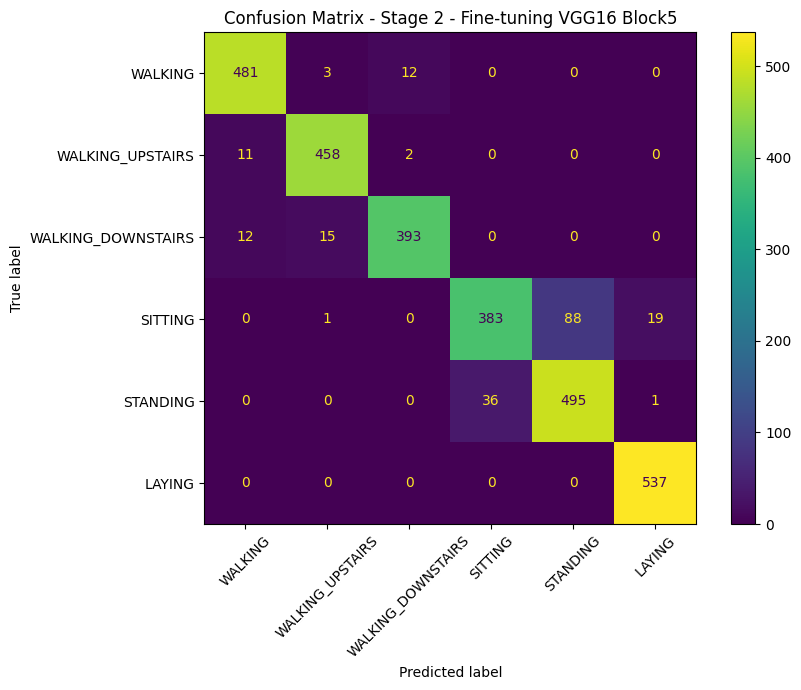

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
================ Stage 2 - Fine-tuning VGG16 Block5 Same-Class Distance ================
Target class  : WALKING
Layer         : head_embedding
Metric        : cosine
Mean distance : 0.0363
Std distance  : 0.0494


In [13]:
# 9. Stage 2: Fine-tune Last VGG Block
# Encoder state:
# - VGG16 block1~block4 frozen
# - VGG16 block5 unfrozen

print("================ Stage 2: Fine-tune VGG Block5 ================")

base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

print("================ Trainable Layers Before Stage 2 ================")
for layer in base_model.layers:
    print(f"{layer.name:25s} trainable={layer.trainable}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage2 = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history_stage2 = model.fit(
    train_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks_stage2,
    verbose=1
)

stage2_result, stage2_cm = evaluate_model_simple(
    model=model,
    test_ds=test_ds,
    y_test=y_test,
    class_names=class_names,
    stage_name="Stage 2 - Fine-tuning VGG16 Block5"
)

emb_stage2, _ = extract_embeddings(
    model=model,
    X=X_test,
    y=y_test,
    layer_name=EMBEDDING_LAYER_FOR_ANALYSIS,
    n_samples=N_TSNE_SAMPLES
)

stage2_distance = measure_same_class_distance(
    model=model,
    X=X_test,
    y=y_test,
    target_class=TARGET_CLASS,
    class_names=class_names,
    stage_name="Stage 2 - Fine-tuning VGG16 Block5",
    layer_name=EMBEDDING_LAYER_FOR_ANALYSIS,
    n_samples=N_DISTANCE_SAMPLES,
    metric=DISTANCE_METRIC
)

In [14]:
# 10. Accuracy / Macro F1 Comparison

print("================ Stage 1 vs Stage 2 Performance Comparison ================")

for result in [stage1_result, stage2_result]:
    print(f"\n[{result['stage']}]")
    print(f"Accuracy : {result['accuracy']:.4f}")
    print(f"Macro F1 : {result['macro_f1']:.4f}")

================ Stage 1 vs Stage 2 Performance Comparison ================

[Stage 1 - Linear Probing]
Accuracy : 0.8880
Macro F1 : 0.8848

[Stage 2 - Fine-tuning VGG16 Block5]
Accuracy : 0.9321
Macro F1 : 0.9317


In [15]:
# 11. Same-Class Distance Comparison

distance_df = pd.DataFrame([
    before_distance,
    stage1_distance,
    stage2_distance
])

print("================ Same-Class Distance Comparison ================")

for result in [before_distance, stage1_distance, stage2_distance]:
    print(f"\n[{result['stage']}]")
    print(f"Target Class  : {result['target_class']}")
    print(f"Layer         : {result['layer']}")
    print(f"Metric        : {result['metric']}")
    print(f"Mean Distance : {result['mean_distance']:.4f}")
    print(f"Std Distance  : {result['std_distance']:.4f}")
    print(f"Min Distance  : {result['min_distance']:.4f}")
    print(f"Max Distance  : {result['max_distance']:.4f}")

================ Same-Class Distance Comparison ================

[Before Training]
Target Class  : WALKING
Layer         : head_embedding
Metric        : cosine
Mean Distance : 0.0403
Std Distance  : 0.0165
Min Distance  : 0.0070
Max Distance  : 0.1205

[Stage 1 - Linear Probing]
Target Class  : WALKING
Layer         : head_embedding
Metric        : cosine
Mean Distance : 0.1047
Std Distance  : 0.0913
Min Distance  : 0.0030
Max Distance  : 0.5346

[Stage 2 - Fine-tuning VGG16 Block5]
Target Class  : WALKING
Layer         : head_embedding
Metric        : cosine
Mean Distance : 0.0363
Std Distance  : 0.0494
Min Distance  : 0.0006
Max Distance  : 0.2796


================ t-SNE Comparison ================
Before Training embedding shape: (1000, 128)
Stage 1 embedding shape: (1000, 128)
Stage 2 embedding shape: (1000, 128)


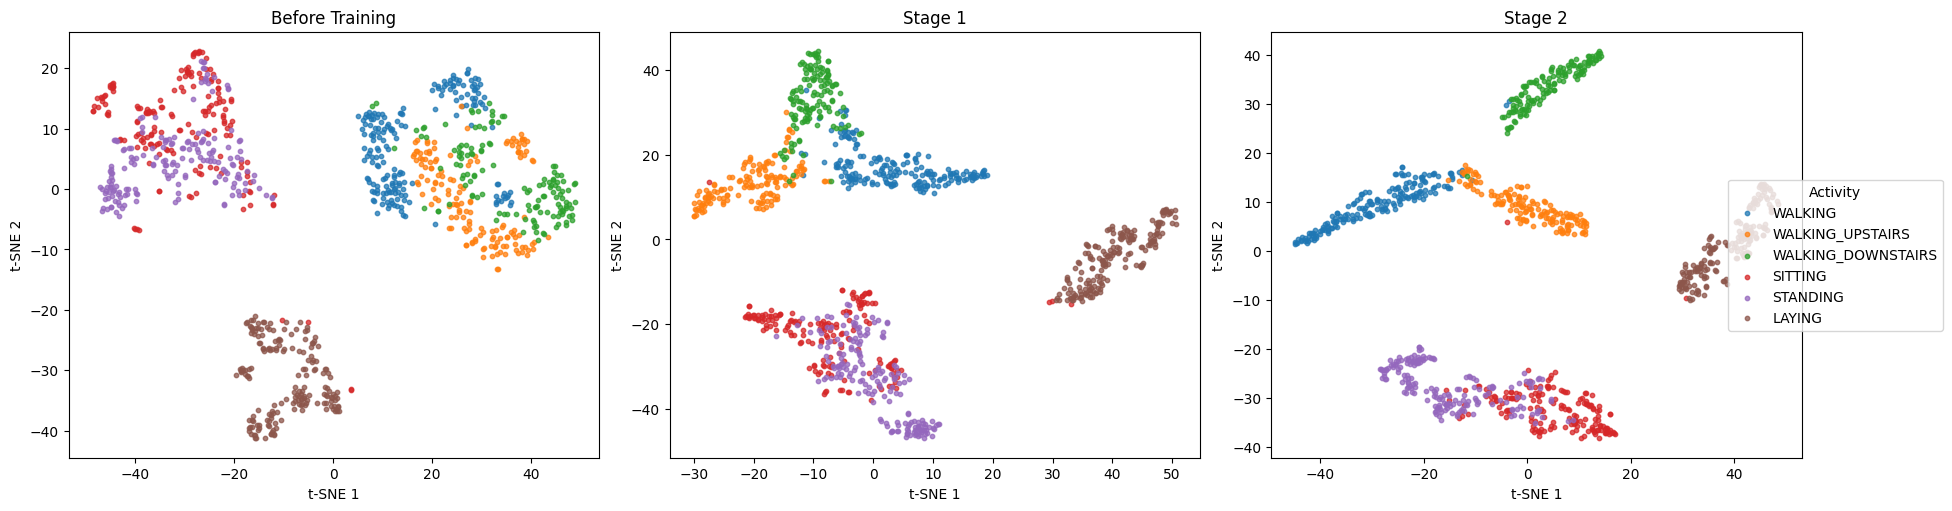

In [16]:
# 12. t-SNE Visualization Summary
# t-SNE는 마지막에 한 번에 출력
# 기준 layer: head_embedding
# - Before Training: 학습 전 classifier head 표현
# - Stage 1       : head만 학습한 뒤 표현
# - Stage 2       : block5 + head fine-tuning 뒤 표현

tsne_results = plot_tsne_comparison_row(
    embeddings_list=[
        emb_before,
        emb_stage1,
        emb_stage2
    ],
    y=y_vis,
    class_names=class_names,
    titles=[
        "Before Training",
        "Stage 1",
        "Stage 2"
    ]
)